In [11]:
from langgraph.graph import StateGraph ,START ,END
from langchain_mistralai import ChatMistralAI
from typing import TypedDict
from dotenv import load_dotenv

In [20]:
load_dotenv()
model  = ChatMistralAI(model_name="ministral-3b-latest",temperature=0.7)

In [21]:
class BlogState(TypedDict):
    topic: str
    outline: str
    blog_post: str
    evaluation: str

In [22]:
def outline_function(state: BlogState) -> BlogState:
# fetch title
    topic = state['topic']
# call llm gen outline
    prompt = f"Create an outline for a blog post about: {topic}"
    outline = model.invoke(prompt).content
# update state with outline
    state['outline'] = outline
    return state

In [23]:
def blog_post_function(state: BlogState) -> BlogState:
# fetch outline
    outline = state['outline']
# call llm gen blog post
    prompt = f"Write a blog post based on the following outline: {outline}"
    blog_post = model.invoke(prompt).content
# update state with blog post
    state['blog_post'] = blog_post
    return state

In [24]:
def evalute(state:BlogState)->BlogState:
    blog_post = state['outline']
    prompt = f"based on this outline evaluate my blog post: {blog_post}"
    evaluation = model.invoke(prompt).content
    state['evaluation'] = evaluation
    return state


In [25]:
graph = StateGraph(BlogState)
graph.add_node("outline", outline_function)
graph.add_node("blog_post", blog_post_function)
graph.add_node("eval" , evalute)
graph.add_edge(START,'outline')
graph.add_edge('outline' , 'blog_post')
graph.add_edge('blog_post' ,'eval')
graph.add_edge('eval' , END)
workflow = graph.compile()



In [26]:
start = {'topic': "The Future of AI in Education"}
final_state = workflow.invoke(start)
print(final_state['evaluation']) 

Your **blog post outline for *"The Future of AI in Education"*** is **well-structured, comprehensive, and engaging**, covering a broad range of topics while maintaining clarity and depth. Below is a **detailed evaluation** with suggestions for refinement, improvements, and actionable insights to enhance readability, impact, and SEO.

---

### **Strengths of Your Outline**
1. **Strong Hook & Introduction**
   - The introduction effectively sets the stage with a thought-provoking question and a clear purpose. The preview of sections helps readers understand the scope.

2. **Balanced Coverage of AI’s Role**
   - You’ve included **current implementations, future trends, and ethical concerns**, which is essential for a well-rounded discussion.

3. **Actionable Sections**
   - The **"Preparing for the AI-Educated Future"** and **"Call to Action"** sections encourage reader engagement, which is great for SEO and community building.

4. **SEO & Engagement Considerations**
   - You’ve identifie

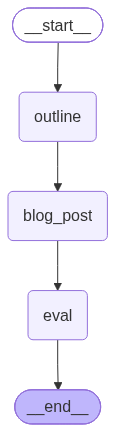

In [27]:
from IPython.display import Image, display 
display(Image(workflow.get_graph().draw_mermaid_png()))

### testing-------------

In [ ]:
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv

In [ ]:
load_dotenv()
model  = ChatMistralAI()

In [ ]:
prompt = "Hi! Are you reading my key from the .env file?"
response = model.invoke(prompt)
response.content